In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_csv("data/netflix.csv")

In [3]:
#check the first 5 rows of the dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#check the shape of the dataset
df.shape

(8807, 12)

In [5]:
#check the column names of the dataset
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
#check the data types and null values in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
#check the summary statistics of the dataset
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
#check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [9]:
#check for null values in the dataset
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
#fill the null values in the dataset with appropriate values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [11]:
#check for null values in the "duration" column
df[df["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [12]:
#drop the rows with null values in the "duration" column
df.dropna(subset=["duration"], inplace=True)

In [13]:
#check the data type of the "date_added" column
df["date_added"].dtype

<StringDtype(storage='python', na_value=nan)>

In [14]:
#strip any leading or trailing whitespace from the "date_added" column
df["date_added"] = df["date_added"].str.strip()

In [15]:
#convert the "date_added" column to datetime format
df["date_added"] = pd.to_datetime(df["date_added"])

In [16]:
#check the data types and null values in the dataset
df.info()

<class 'pandas.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8804 non-null   str           
 1   type          8804 non-null   str           
 2   title         8804 non-null   str           
 3   director      8804 non-null   str           
 4   cast          8804 non-null   str           
 5   country       8804 non-null   str           
 6   date_added    8794 non-null   datetime64[us]
 7   release_year  8804 non-null   int64         
 8   rating        8804 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8804 non-null   str           
 11  description   8804 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 894.2 KB


In [17]:
#check for null values in the dataset
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [ ]:
#create a new column "year_added" that contains the year when the show was added to Netflix
df["year_added"] = df["date_added"].dt.year

In [ ]:
#Create the month
df["month_added"] = df["date_added"].dt.month_name()

In [20]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


In [ ]:
#check the unique values in the "type" column
df["type"].value_counts()

type
Movie      6128
TV Show    2676
Name: count, dtype: int64

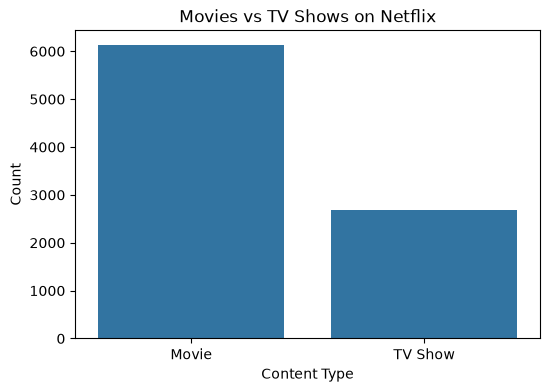

In [ ]:
#Analysis 1: Movies vs TV Shows
# Plot the distribution of content types
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

## Business Insights
**Core Finding:** The Netflix catalog contains significantly more **Movies** than **TV Shows**, indicating that movies make up the vast majority of the platform's content library.

In [ ]:
#Analysis 2: Top 10 Countries
#Spliting the "country" column into multiple rows and counting the occurrences of each country
country_counts = (
    df["country"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

country_counts

country
United States     3686
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

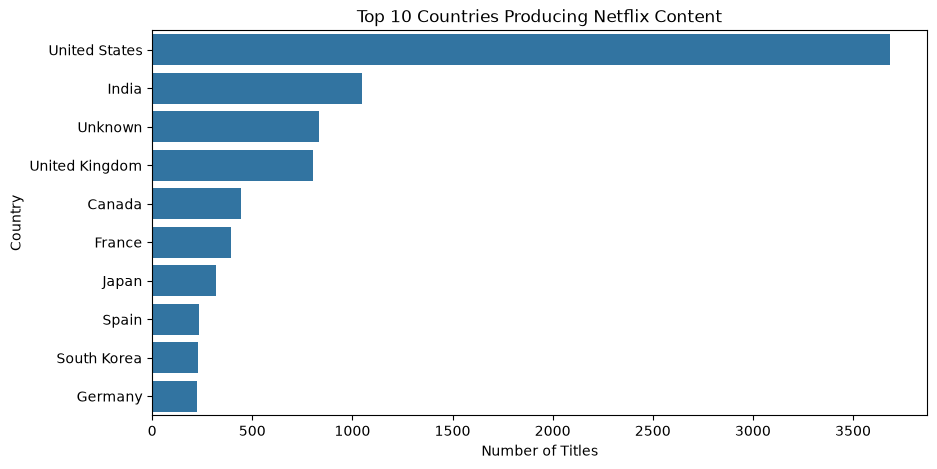

In [ ]:
#Plot the top 10 countries producing Netflix content
plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Insight

The United States contributes the largest number of Netflix titles,
followed by India and the United Kingdom.

In [27]:
#Analysis 3: Top Genres
#Spliting the "listed_in" column into multiple rows and counting the occurrences of each genre
genre_counts = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genre_counts

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

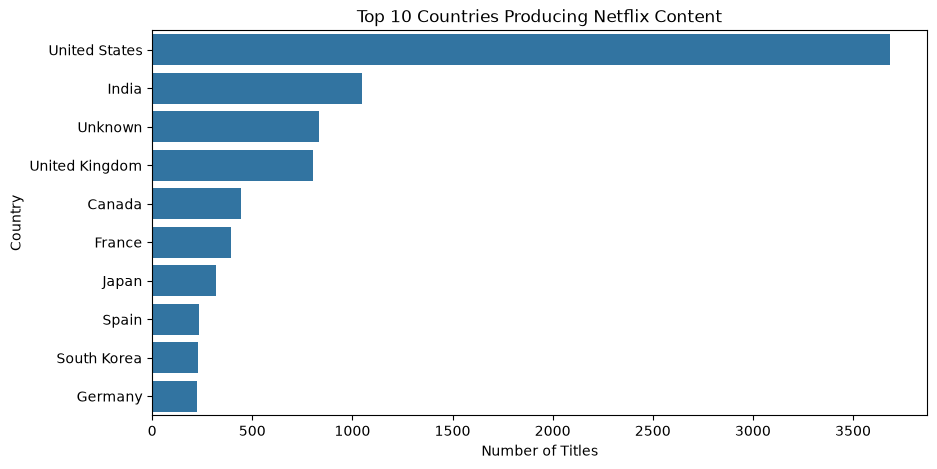

In [28]:
#Plot the top 10 countries producing Netflix content
plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Insight

Drama and International Movies are among the most common genres,
indicating Netflix has a diverse global content library.

In [30]:
#Analysis 4: Netflix Growth Over Time
content_by_year = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

content_by_year

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     427
2017.0    1187
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

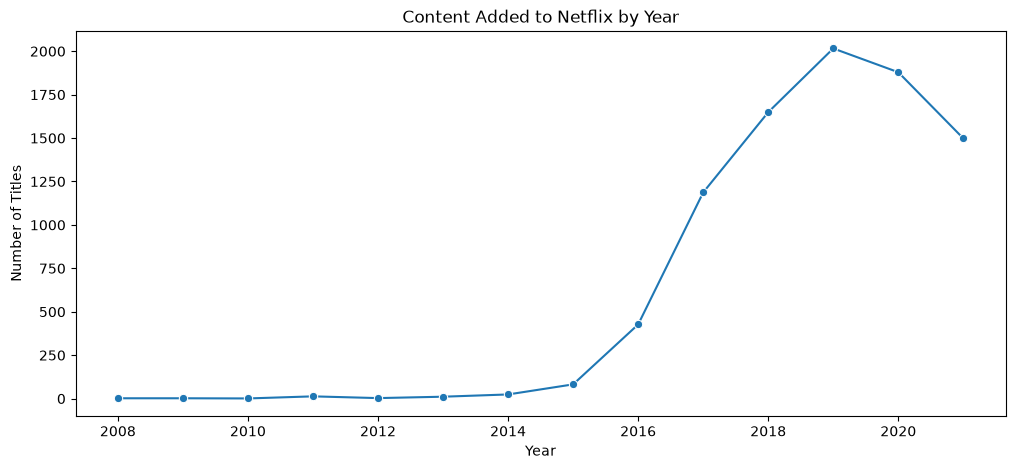

In [31]:
#Plot the growth of Netflix content over time
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=content_by_year.index,
    y=content_by_year.values,
    marker="o"
)

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

### Insight

Netflix experienced rapid growth in content additions after 2015,
reaching its highest additions around 2019 before slowing down.

In [32]:
#Analysis 5: Ratings Distribution
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
Name: count, dtype: int64

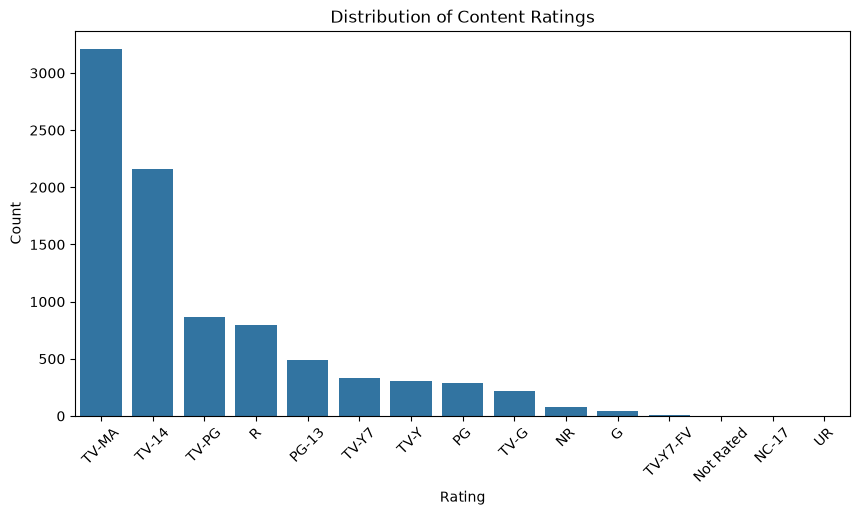

In [33]:
#Plot the distribution of content ratings
plt.figure(figsize=(10, 5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.xticks(rotation=45)

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

### Insight

TV-MA and TV-14 are the most common ratings,
showing that much of Netflix's content targets teenagers and adults.

In [36]:
#Analysis 6: Top Directors
director_counts = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

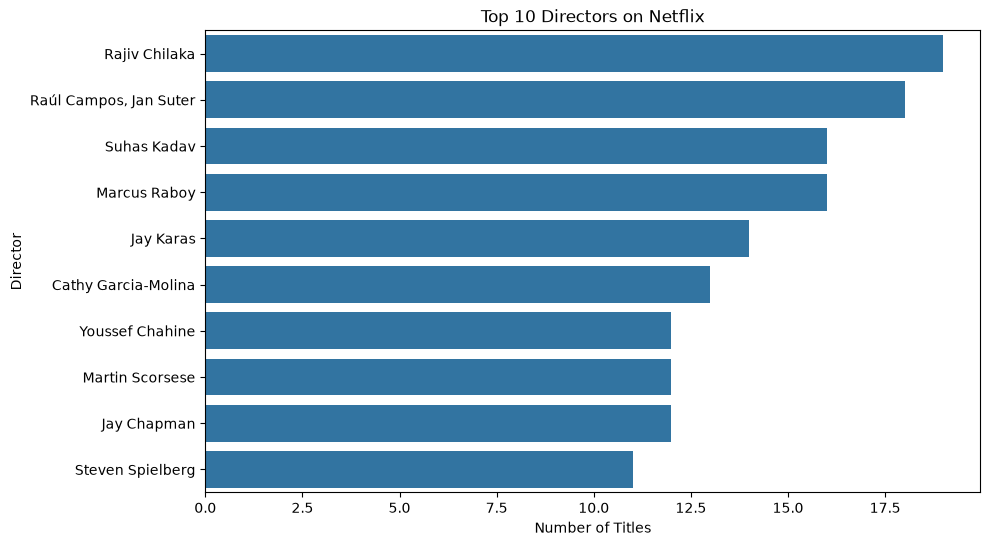

In [37]:
#Plot the top 10 directors on Netflix
plt.figure(figsize=(10, 6))

sns.barplot(
    x=director_counts.values,
    y=director_counts.index
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()